### Exercise 1: solve the EDO

Use FEM to solve the next EDO (use the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
\dfrac{d^2y}{dx^2}=-xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(2-x)-x
\end{equation}

### Exercise 2: Solve the EDO:  

see pag 36: https://cimec.org.ar/foswiki/pub/Main/Cimec/CursoFEM/cursofem_1.pdf

$-\dfrac{d^2U}{dx^2}(x)=\sin(\pi x)\,,$
in $0\le x\le 1$, with $U(0)=U(1)=0$.

The exact solution is known $U(x)=\dfrac{1}{\pi^2}\sin(\pi x)$.

In [503]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import scipy.integrate as integrate
import matplotlib.pyplot as plt

1. \begin{equation}
\dfrac{d^2y}{dx^2}=-xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}

Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$.

In [504]:
def f(x):
  return -x*np.exp(x)

In [505]:
def solucion(x):
  u = 1-np.exp(1)+(np.exp(x)*(2-x))-x
  return u

x_new = np.linspace(0,1)
y_new = solucion(x_new)

y = np.interp(x_new, xi, sol)

In [506]:
def FEM(N,f,xa,xb,Ua,Ub):

  h = (xb-xa)/(N-1)
  u = np.zeros(N , float);
  b = np.zeros(N, float );

  #steps: elements, malla
  xi = np.zeros(N ,float );
  for i in range(0,N):
      xi[i] = i*h

  # A matrix (integrated analytical)
  A = np.zeros((N, N), float );
  for i in range( 1 , N):
      A[i-1 , i-1 ] = A[ i-1 , i-1 ] + 1/ h
      A[i-1 , i ] = A[ i-1 , i ] - 1/h
      A[i , i-1 ] = A[ i-1 , i ]
      A[i , i ]= A[ i , i ] + 1/ h

  #phi(x) functions
  def lin1(x, x1, x2):
      return (x-x1)/(x2-x1)

  def lin2(x, x1, x2):
      return (x2-x)/(x2-x1)

  #integrals for bi elements using quad
  def int1(min, max):
      return integrate.quad(lambda x: -f(x)*lin1(x, min, max), min, max)[0]

  def int2(min, max):
      return integrate.quad(lambda x: -f(x)*lin2(x, min, max), min, max)[0]

  #b matrix (Numerical integration)
  b = np.zeros(N, float);

  for i in range(1 , N):
      b[i-1] = b[i-1] + int2( xi[i-1], xi[i] )
      b[i] = b[i] + int1( xi[i-1], xi[i] )

  #Initial conditions
  b[0] = Ua
  b[N-1] = Ub

  A[0,:] = 0
  A[0,0] = 1
  A[N-1,:] = 0
  A[N-1, N-1] = 1

  #Solve the system using Gaussian elimination in numpy
  sol = np.linalg.solve(A, b )

  return xi,sol

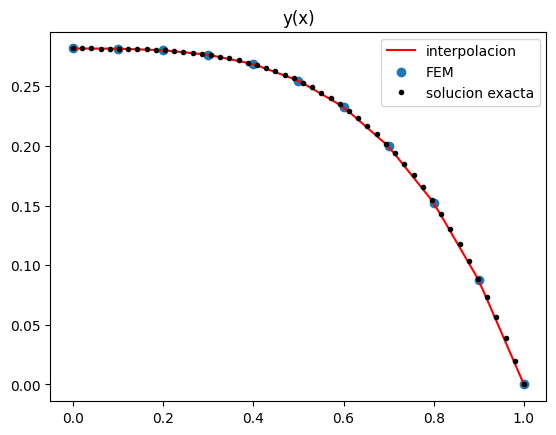

In [507]:
X, Y = FEM(11,f,0,1,3-np.exp(1),0)[0], FEM(11,f,0,1,3-np.exp(1),0)[1]
y = np.interp(x_new,X,Y)
plt.plot(x_new,y, "r", label = "interpolacion")
plt.scatter(X,Y, label = "FEM")
plt.plot(x_new,y_new, "k.", label = "solucion exacta")
plt.title("y(x)")
plt.legend()
plt.show()

 2.  $$ -\dfrac{d^2U}{dx^2}(x)=\sin(\pi x)\,$$
en $$0\le x\le 1$$ con $$U(0)=U(1)=0. $$

In [508]:
def f2(x):
  return -np.sin(np.pi*x)

In [509]:
X,Y = FEM(11,f2,0,1,0,0)
x_n = np.linspace(0,1)
y2 = np.interp(x_n,X,Y)

In [510]:
def exact(x):
  return (1/np.pi**2)*np.sin(np.pi*x)

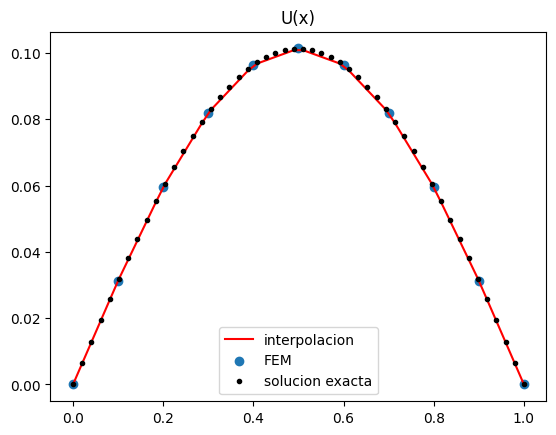

In [513]:
plt.plot(x_n,y2, "r", label = "interpolacion")
plt.scatter(X,Y, label = "FEM")
plt.plot(x_n,exact(x_n), "k.", label = "solucion exacta")
plt.title("U(x)")
plt.legend()
plt.show()